In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [2]:
sns.set_style("whitegrid")
palette =sns.color_palette("crest", n_colors=3)

# Loading Models & Results

lr_model = joblib.load('../models/linear_regression_model.pkl')
ridge_model = joblib.load('../models/ridge_regression_model.pkl')
lasso_model = joblib.load('../models/lasso_regression_model.pkl')
scalar = joblib.load('../models/feature_scaler.pkl')
results = joblib.load('../models/model_results_summary.pkl')


X_train = results['X_train']
X_test = results['X_test']
y_train = results['y_train']
y_test = results['y_test']
y_train_pred_lr = results['y_train_pred_linear']
y_test_pred_lr = results['y_test_pred_linear']
y_train_pred_ridge = results['y_train_pred_ridge']
y_test_pred_ridge = results['y_test_pred_ridge']
y_train_pred_lasso = results['y_train_pred_lasso']
y_test_pred_lasso = results['y_test_pred_lasso']
features = results['features']
comparison = results['models_comparison']


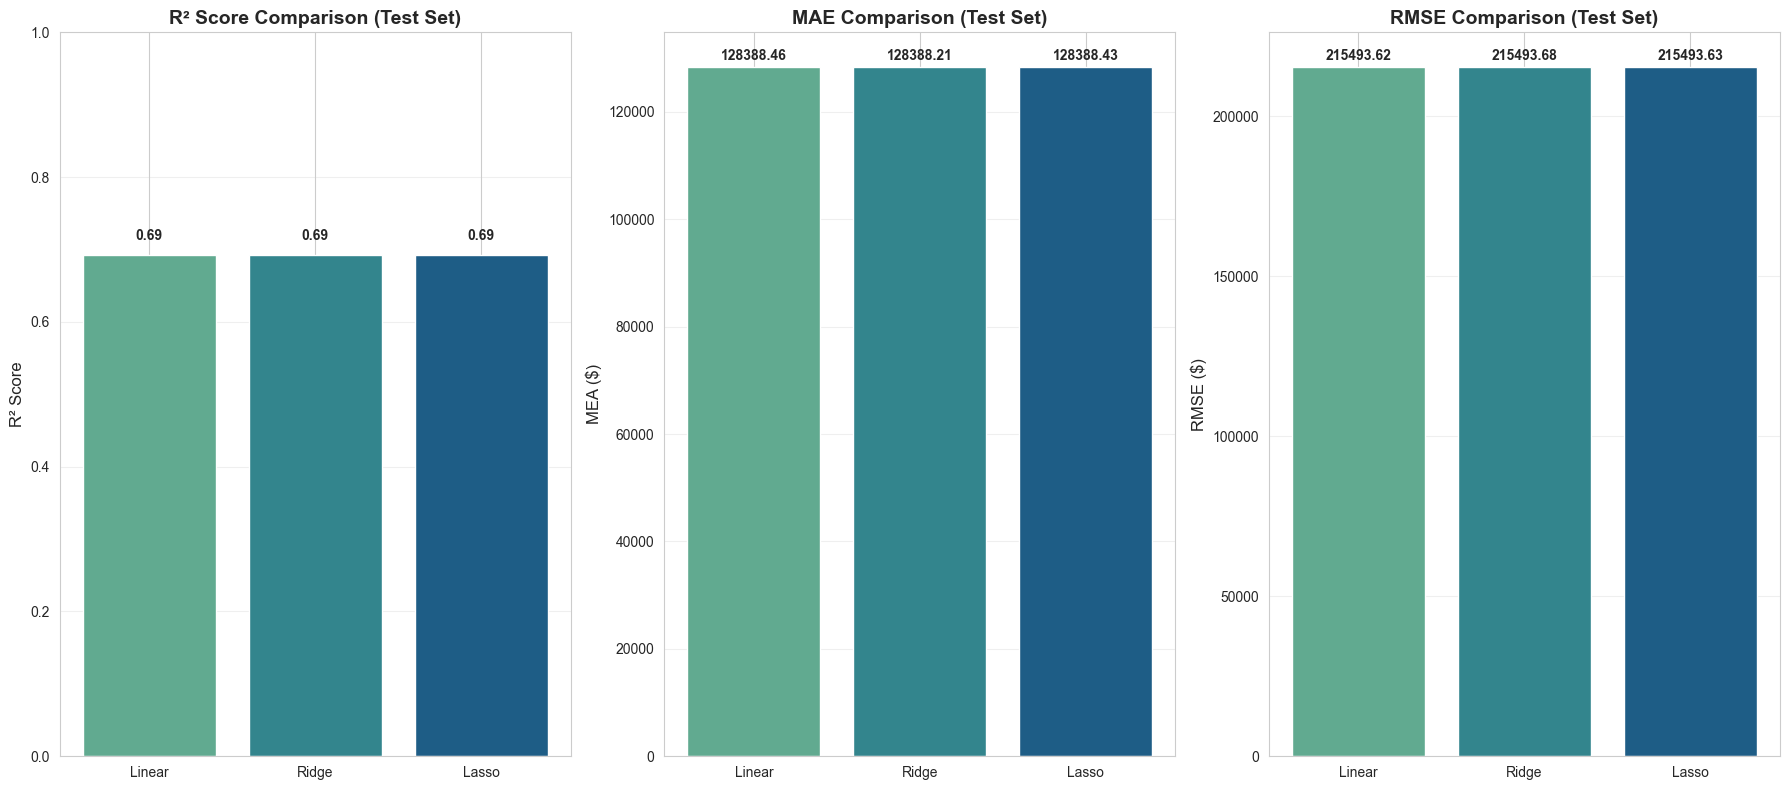

In [4]:
# Model Performance Comparison Visualization

fig, axes = plt.subplots(1, 3, figsize=(18, 8))

models = ['Linear', 'Ridge', 'Lasso']
test_r2 = comparison['R² Test'].values
test_mae = comparison['MAE Test'].values
test_rmse = comparison['RMSE Test'].values


# R² Comparison

axes[0].bar(models, test_r2, color=palette)
axes[0].set_ylabel('R² Score', fontsize=12)
axes[0].set_title('R² Score Comparison (Test Set)', fontsize=14, fontweight='bold')
axes[0].set_ylim(0, 1)
axes[0].grid(True,alpha=0.3, axis='y')
for i, v in enumerate(test_r2):
    axes[0].text(i, v + 0.02, f"{v:.2f}", ha='center', fontsize=10, fontweight='bold')

# MAE Comparison
axes[1].bar(models, test_mae, color=palette)
axes[1].set_ylabel('MEA ($)', fontsize=12)
axes[1].set_title('MAE Comparison (Test Set)', fontsize=14, fontweight='bold')
axes[1].grid(True,alpha=0.3, axis='y')
for i, v in enumerate(test_mae):
    axes[1].text(i, v + 0.01 * max(test_mae), f"{v:.2f}", ha='center', fontsize=10, fontweight='bold')

# RMSE Comparison
axes[2].bar(models, test_rmse, color=palette)
axes[2].set_ylabel('RMSE ($)', fontsize=12)
axes[2].set_title('RMSE Comparison (Test Set)', fontsize=14, fontweight='bold')
axes[2].grid(True,alpha=0.3, axis='y')
for i, v in enumerate(test_rmse):
    axes[2].text(i, v + 0.01 * max(test_rmse), f"{v:.2f}", ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('../output/figures/model__perf_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

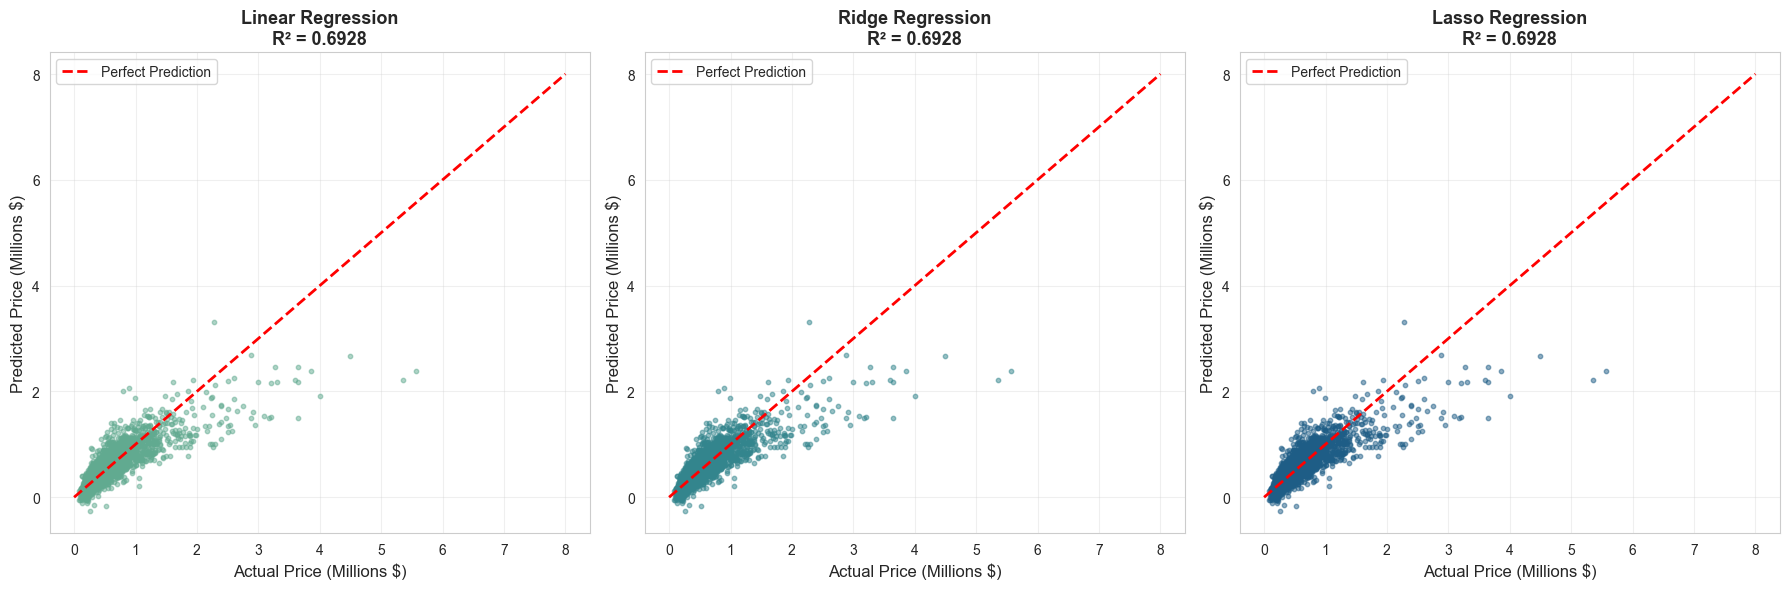

In [5]:
# Prediction vs Actual

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
# Linear Regression
axes[0].scatter(y_test/1000000, y_test_pred_lr/1000000, alpha=0.5, s=10, color=palette[0])
axes[0].plot([0, 8], [0, 8], 'r--', linewidth=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual Price (Millions $)', fontsize=12)
axes[0].set_ylabel('Predicted Price (Millions $)', fontsize=12)
axes[0].set_title(f'Linear Regression\nR² = {r2_score(y_test, y_test_pred_lr):.4f}', 
                 fontsize=13, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Ridge Regression
axes[1].scatter(y_test/1000000, y_test_pred_ridge/1000000, alpha=0.5, s=10, color=palette[1])
axes[1].plot([0, 8], [0, 8], 'r--', linewidth=2, label='Perfect Prediction')
axes[1].set_xlabel('Actual Price (Millions $)', fontsize=12)
axes[1].set_ylabel('Predicted Price (Millions $)', fontsize=12)
axes[1].set_title(f'Ridge Regression\nR² = {r2_score(y_test, y_test_pred_ridge):.4f}', 
                 fontsize=13, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Lasso Regression
axes[2].scatter(y_test/1000000, y_test_pred_lasso/1000000, alpha=0.5, s=10, color=palette[2])
axes[2].plot([0, 8], [0, 8], 'r--', linewidth=2, label='Perfect Prediction')
axes[2].set_xlabel('Actual Price (Millions $)', fontsize=12)
axes[2].set_ylabel('Predicted Price (Millions $)', fontsize=12)
axes[2].set_title(f'Lasso Regression\nR² = {r2_score(y_test, y_test_pred_lasso):.4f}', 
                 fontsize=13, fontweight='bold')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../output/figures/model_prediction_comparison.png', dpi=300, bbox_inches='tight')
plt.show()


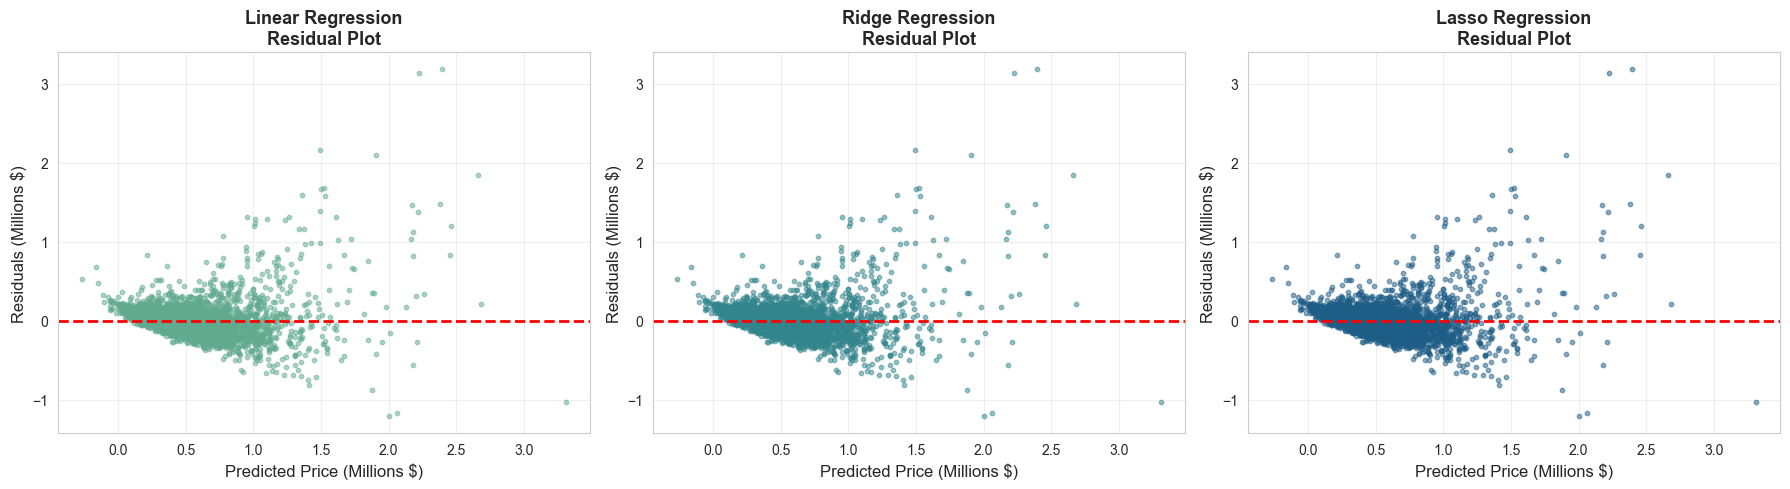

In [6]:
# Residuals Analysis

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Calculate residuals
residuals_lr = y_test - y_test_pred_lr
residuals_ridge = y_test - y_test_pred_ridge
residuals_lasso = y_test - y_test_pred_lasso

# Linear Regression
axes[0].scatter(y_test_pred_lr/1000000, residuals_lr/1000000, alpha=0.5, s=10, color=palette[0])
axes[0].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[0].set_xlabel('Predicted Price (Millions $)', fontsize=12)
axes[0].set_ylabel('Residuals (Millions $)', fontsize=12)
axes[0].set_title('Linear Regression\nResidual Plot', fontsize=13, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Ridge Regression
axes[1].scatter(y_test_pred_ridge/1000000, residuals_ridge/1000000, alpha=0.5, s=10, color=palette[1])
axes[1].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[1].set_xlabel('Predicted Price (Millions $)', fontsize=12)
axes[1].set_ylabel('Residuals (Millions $)', fontsize=12)
axes[1].set_title('Ridge Regression\nResidual Plot', fontsize=13, fontweight='bold')
axes[1].grid(True, alpha=0.3)

# Lasso Regression
axes[2].scatter(y_test_pred_lasso/1000000, residuals_lasso/1000000, alpha=0.5, s=10, color=palette[2])
axes[2].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[2].set_xlabel('Predicted Price (Millions $)', fontsize=12)
axes[2].set_ylabel('Residuals (Millions $)', fontsize=12)
axes[2].set_title('Lasso Regression\nResidual Plot', fontsize=13, fontweight='bold')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../output/figures/models_residual_plot_comparison.png', dpi=300, bbox_inches='tight')
plt.show()


Linear Regression - Top 5 Features:
    Feature   Coefficient
sqft_living 159734.933843
      grade 121913.359453
  house_age  78688.889542
        lat  75824.511381
 waterfront  48323.119703

Ridge Regression - Top 5 Features:
    Feature   Coefficient
sqft_living 159732.906973
      grade 121913.066645
  house_age  78688.082528
        lat  75824.333563
 waterfront  48322.907885

Lasso Regression - Top 5 Features:
    Feature   Coefficient
sqft_living 159734.806691
      grade 121913.336351
  house_age  78688.686645
        lat  75824.470902
 waterfront  48323.057883


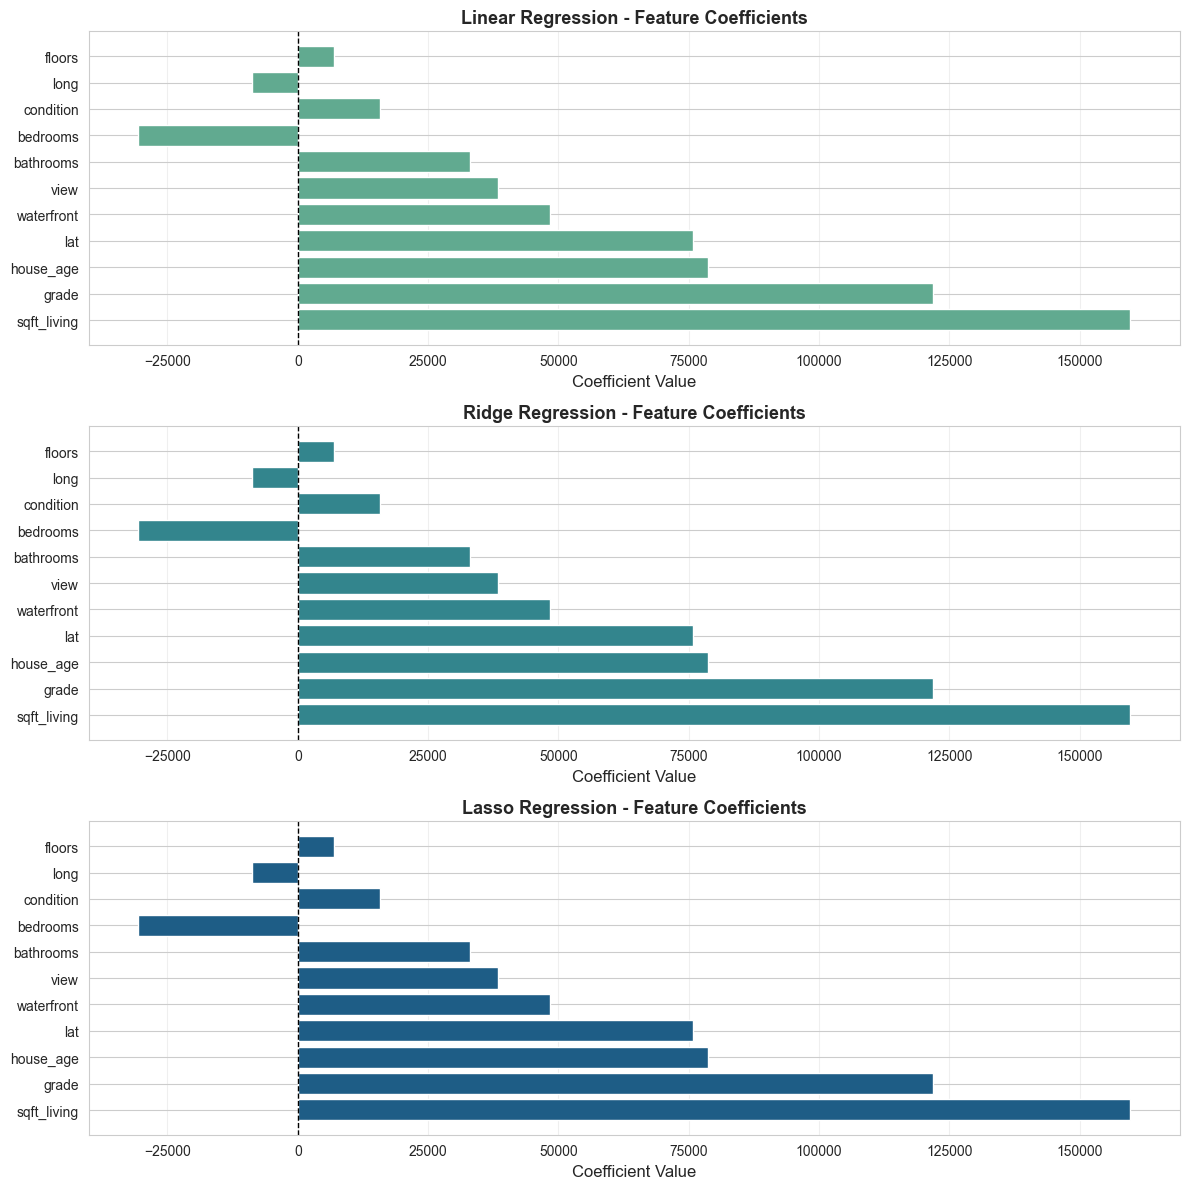

In [7]:
# Feature Importance Visualization

lr_coef = pd.DataFrame({'Feature': features, 'Coefficient': lr_model.coef_})
ridge_coef = pd.DataFrame({'Feature': features, 'Coefficient': ridge_model.coef_})
lasso_coef = pd.DataFrame({'Feature': features, 'Coefficient': lasso_model.coef_})

# Sort by absolute value
lr_coef = lr_coef.reindex(lr_coef['Coefficient'].abs().sort_values(ascending=False).index)
ridge_coef = ridge_coef.reindex(ridge_coef['Coefficient'].abs().sort_values(ascending=False).index)
lasso_coef = lasso_coef.reindex(lasso_coef['Coefficient'].abs().sort_values(ascending=False).index)

print("\nLinear Regression - Top 5 Features:")
print(lr_coef.head().to_string(index=False))

print("\nRidge Regression - Top 5 Features:")
print(ridge_coef.head().to_string(index=False))

print("\nLasso Regression - Top 5 Features:")
print(lasso_coef.head().to_string(index=False))

# Visualize coefficients
fig, axes = plt.subplots(3, 1, figsize=(12, 12))

# Linear Regression
axes[0].barh(lr_coef['Feature'], lr_coef['Coefficient'], color=palette[0])
axes[0].set_xlabel('Coefficient Value', fontsize=12)
axes[0].set_title('Linear Regression - Feature Coefficients', fontsize=13, fontweight='bold')
axes[0].axvline(x=0, color='black', linestyle='--', linewidth=1)
axes[0].grid(True, alpha=0.3, axis='x')

# Ridge Regression
axes[1].barh(ridge_coef['Feature'], ridge_coef['Coefficient'], color=palette[1])
axes[1].set_xlabel('Coefficient Value', fontsize=12)
axes[1].set_title('Ridge Regression - Feature Coefficients', fontsize=13, fontweight='bold')
axes[1].axvline(x=0, color='black', linestyle='--', linewidth=1)
axes[1].grid(True, alpha=0.3, axis='x')

# Lasso Regression
axes[2].barh(lasso_coef['Feature'], lasso_coef['Coefficient'], color=palette[2])
axes[2].set_xlabel('Coefficient Value', fontsize=12)
axes[2].set_title('Lasso Regression - Feature Coefficients', fontsize=13, fontweight='bold')
axes[2].axvline(x=0, color='black', linestyle='--', linewidth=1)
axes[2].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('../output/figures/feature_importance_comparison.png', dpi=300, bbox_inches='tight')
plt.show()



    Feature        Linear         Ridge         Lasso
   bedrooms -30615.560728 -30614.563482 -30615.297108
  bathrooms  33085.418364  33086.005977  33085.232714
sqft_living 159734.933843 159732.906973 159734.806691
     floors   6975.472528   6975.422209   6975.344980
 waterfront  48323.119703  48322.907885  48323.057883
       view  38464.109092  38464.472768  38464.113965
  condition  15794.419318  15794.480720  15794.324166
      grade 121913.359453 121913.066645 121913.336351
  house_age  78688.889542  78688.082528  78688.686645
        lat  75824.511381  75824.333563  75824.470902
       long  -8789.776628  -8789.753193  -8789.719353


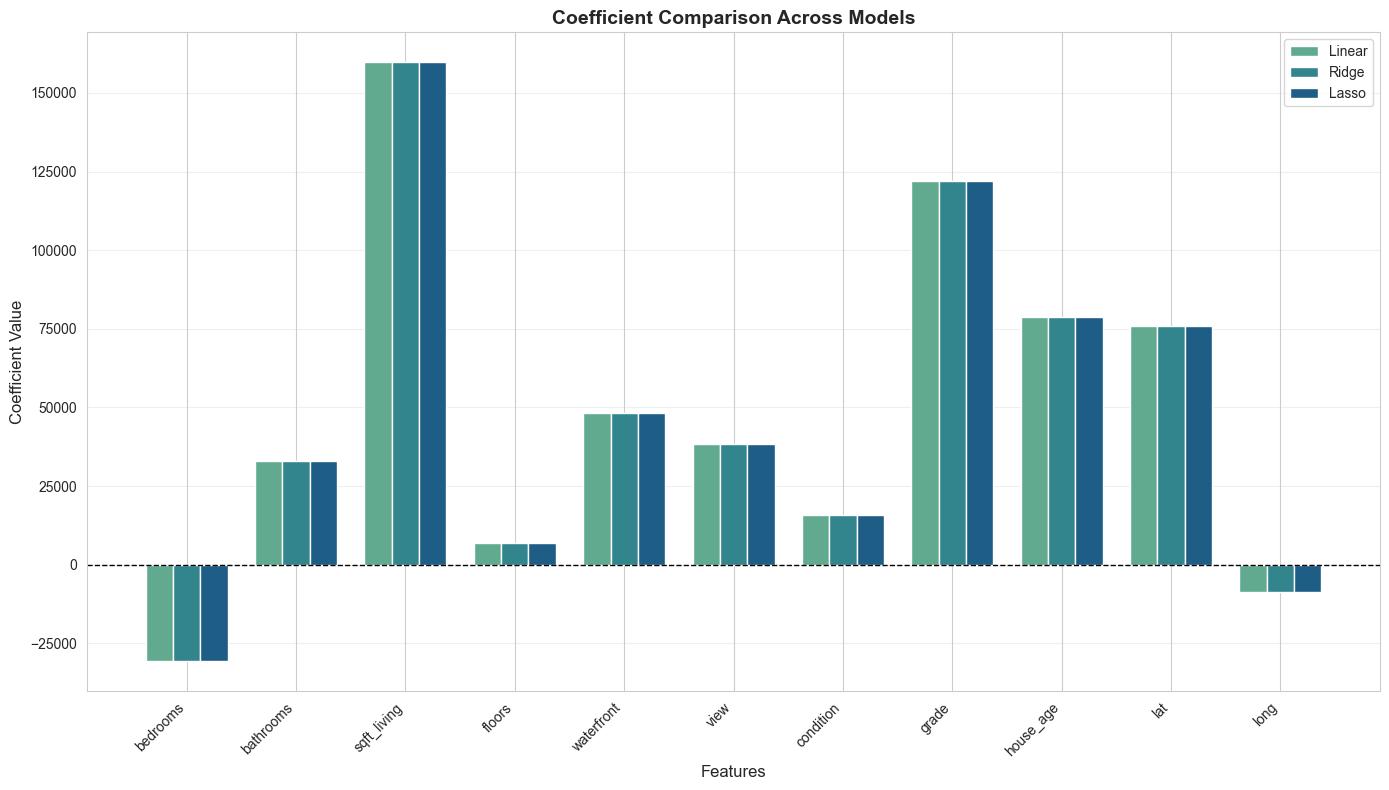

In [8]:
# Coefficient Comparison

coef_comparison = pd.DataFrame({
    'Feature': features,
    'Linear': lr_model.coef_,
    'Ridge': ridge_model.coef_,
    'Lasso': lasso_model.coef_
})

print("\n" + coef_comparison.to_string(index=False))

# Visualize side-by-side
fig, ax = plt.subplots(figsize=(14, 8))

x = np.arange(len(features))
width = 0.25

ax.bar(x - width, coef_comparison['Linear'], width, label='Linear', color=palette[0])
ax.bar(x, coef_comparison['Ridge'], width, label='Ridge', color=palette[1])
ax.bar(x + width, coef_comparison['Lasso'], width, label='Lasso', color=palette[2])

ax.set_xlabel('Features', fontsize=12)
ax.set_ylabel('Coefficient Value', fontsize=12)
ax.set_title('Coefficient Comparison Across Models', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(features, rotation=45, ha='right')
ax.legend()
ax.axhline(y=0, color='black', linestyle='--', linewidth=1)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('../output/figures/model_coefficient_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

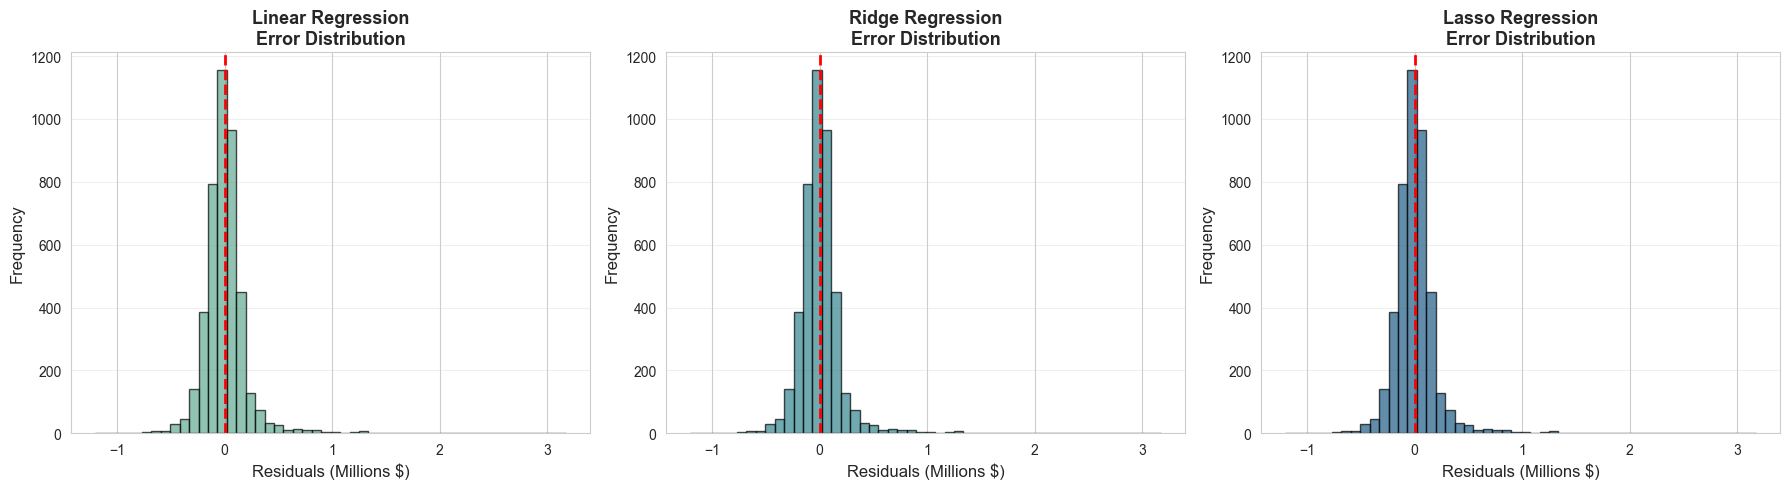

In [9]:
#Error Distribution Analysis

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Linear Regression
axes[0].hist(residuals_lr/1000000, bins=50, color=palette[0], edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Residuals (Millions $)', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].set_title('Linear Regression\nError Distribution', fontsize=13, fontweight='bold')
axes[0].axvline(x=0, color='red', linestyle='--', linewidth=2)
axes[0].grid(True, alpha=0.3, axis='y')

# Ridge Regression
axes[1].hist(residuals_ridge/1000000, bins=50, color=palette[1], edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Residuals (Millions $)', fontsize=12)
axes[1].set_ylabel('Frequency', fontsize=12)
axes[1].set_title('Ridge Regression\nError Distribution', fontsize=13, fontweight='bold')
axes[1].axvline(x=0, color='red', linestyle='--', linewidth=2)
axes[1].grid(True, alpha=0.3, axis='y')

# Lasso Regression
axes[2].hist(residuals_lasso/1000000, bins=50, color=palette[2], edgecolor='black', alpha=0.7)
axes[2].set_xlabel('Residuals (Millions $)', fontsize=12)
axes[2].set_ylabel('Frequency', fontsize=12)
axes[2].set_title('Lasso Regression\nError Distribution', fontsize=13, fontweight='bold')
axes[2].axvline(x=0, color='red', linestyle='--', linewidth=2)
axes[2].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('../output/figures/models_error_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

## Reflection

### 1. Overfitting
    - There is a balance between model complexity and generalization. 
    - **Performance Metrics**
        - Training R² = 0.6925
        - Test R² = 0.6928
        - Difference = 0.0003 (essentially 0)
    - Test performance slightly *exceeds* training performance (No Overfit).

### 2. Regularization
    - **Ridge**
        - Many correlated features, wanted to keep all of them
    - **Lasso**
        - Many features so wanted automatic selection. 
    **Alpha Testing Results:**
       - Ridge Performance:
            - Alpha = 0.1: R² = 0.6928 (optimal)
            - Alpha = 100: R² = 0.6926 (minimal change)
            - Alpha = 1000: R² = 0.6899 (degradation begins)

        - Lasso Performance:
            - Alpha = 0.1: R² = 0.6928, Features = 12/12 (optimal)
            - Alpha = 100: R² = 0.6928, Features = 12/12 (still all retained)
            - Alpah = 1000: R² = 0.6924, Features = 11-12/12 (slight elimination)
    
    - Since the perofrmance across Linear, Ridge, & Lasso are identical,
        - After removing sqft_above, remaining features had low multicollinearity. 
        - All features are valuable
        - No weak predictors - strong -> Moderate Features

### Dataset Limitations
    - Additional features might help in predictions are
        - School district scores? 
        - Property conditions values, instead of scores
        - Promixity to amenities like Gym, Urgent Care, Pharmacy, Groceries etc.
        - Safety Score?
        - Time on Market before sale? Zillow & other sites gives this info..